# ***TRATAMIENTO DE LAS PROBLEMÁTICAS***

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv('../data/diabetes_preprocesado.csv', sep=",", quotechar='"')

y = df["readmitted"]
X = df.drop(columns=["readmitted"])

X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

## 1- Datos desbalanceados

Antes de SMOTE:
readmitted
0    41870
1    27719
2     8853
Name: count, dtype: int64

Después de SMOTE:
readmitted
0    41870
1    41870
2    41870
Name: count, dtype: int64


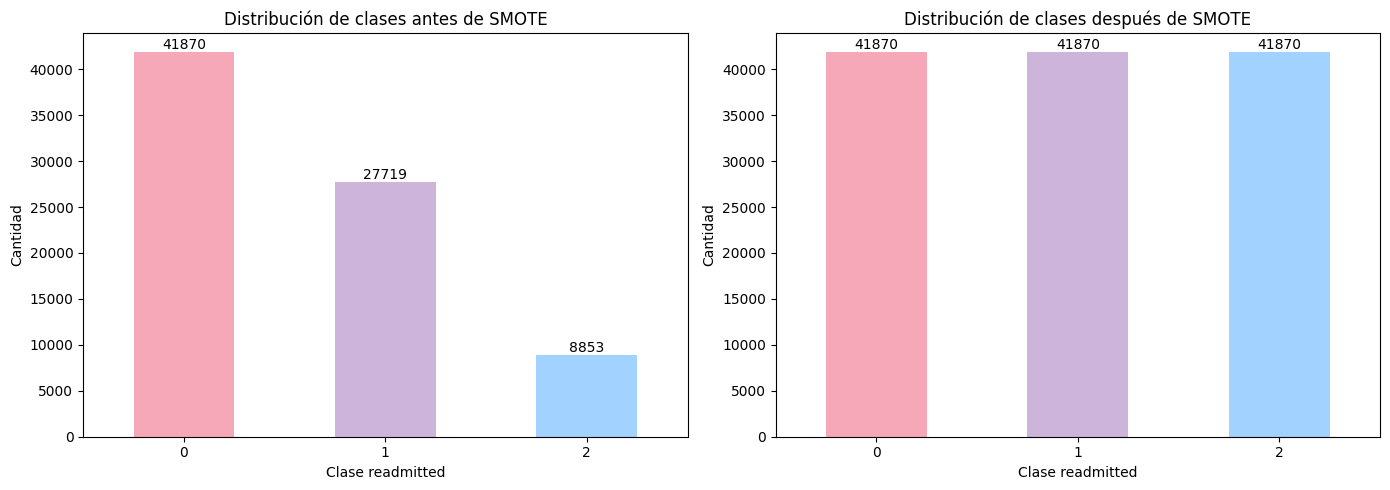

In [4]:
# Distribución antes de SMOTE
y_train_counts = pd.Series(y_train).value_counts()

print("Antes de SMOTE:")
print(y_train_counts)

# Aplicar SMOTE solo al entrenamiento
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


# Distribución después de SMOTE
y_train_smote_counts = pd.Series(y_train_smote).value_counts()

print("\nDespués de SMOTE:")
print(y_train_smote_counts)

# Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#F7A8B8', '#CDB4DB', '#A2D2FF']  # rosa, lila, azul pastel

# Antes
y_train_counts.plot(
    kind='bar',
    ax=axes[0],
    color=colors
)

axes[0].set_title("Distribución de clases antes de SMOTE")
axes[0].set_xlabel("Clase readmitted")
axes[0].set_ylabel("Cantidad")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

for p in axes[0].patches:
    axes[0].annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

# Después
y_train_smote_counts.plot(
    kind='bar',
    ax=axes[1],
    color=colors
)

axes[1].set_title("Distribución de clases después de SMOTE")
axes[1].set_xlabel("Clase readmitted")
axes[1].set_ylabel("Cantidad")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

for p in axes[1].patches:
    axes[1].annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.savefig("../visualizacion_problematicas/smote_distribucion_clases.png", dpi=300, bbox_inches="tight")
plt.show()

## 2- Sesgo y Fairness